# 1.데이터 전처리

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# CSV 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/IBAS ALPHA/data/치매안심병원_프로젝트/output.csv'

# CSV 파일 읽어오기 (인코딩 설정)
try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("File read successfully with utf-8 encoding.")
except UnicodeDecodeError:
    print("utf-8 encoding failed, trying euc-kr encoding.")
    try:
        df = pd.read_csv(file_path, encoding='euc-kr')
        print("File read successfully with euc-kr encoding.")
    except UnicodeDecodeError:
        print("euc-kr encoding failed, trying cp949 encoding.")
        try:
            df = pd.read_csv(file_path, encoding='cp949')
            print("File read successfully with cp949 encoding.")
        except UnicodeDecodeError:
            print("cp949 encoding failed. Please check the file encoding.")

# 데이터프레임 확인
df.head()

File read successfully with utf-8 encoding.


,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수
0,서울특별시,서울_종로구,27661.5,15238.5,3127.29,11.31,484.73,6419.92,23.21,8.5,14447.0,1,20,7,0,102,458,496
1,서울특별시,서울_중구,24713.5,13792.0,2662.26,10.77,412.65,5671.50,22.95,9.7,14734.0,1,16,4,0,85,528,490
2,서울특별시,서울_용산구,38033.0,21471.5,4249.27,11.17,658.64,8782.64,23.09,7.3,16099.0,0,0,0,0,136,456,337
3,서울특별시,서울_성동구,47964.0,26850.5,4889.99,10.20,757.95,10951.29,22.83,7.0,24162.0,5,85,43,0,228,816,757
4,서울특별시,서울_광진구,54690.5,30211.0,5323.19,9.73,825.09,12342.12,22.57,6.3,28780.0,0,0,0,0,172,1865,925


## `01` 결측치 전처리

In [ ]:
# 결측치 확인
print(df.isnull().sum())

시도                   0
시군구                  0
노인인구수                0
여성노인인구수              0
치매환자수                0
치매환자유병률              0
중증 환자                0
경도인지장애 환자수           0
경도인지장애 환자유병률         0
독거노인가구비율             0
기초연금_수급권자수           1
치매전담형 장기요양기관 수       0
치매전담형 장기요양기관 정원      0
치매전담형 장기요양기관 종사자수    0
치매안심병원 유무            0
시설 수                 0
정원                   0
종사자 수                0
dtype: int64


In [ ]:
# 결측치 처리
df['기초연금_수급권자수'].fillna(df['기초연금_수급권자수'].mean(), inplace=True)

In [ ]:
# 결측치 확인
print(df.isnull().sum())

시도                   0
시군구                  0
노인인구수                0
여성노인인구수              0
치매환자수                0
치매환자유병률              0
중증 환자                0
경도인지장애 환자수           0
경도인지장애 환자유병률         0
독거노인가구비율             0
기초연금_수급권자수           0
치매전담형 장기요양기관 수       0
치매전담형 장기요양기관 정원      0
치매전담형 장기요양기관 종사자수    0
치매안심병원 유무            0
시설 수                 0
정원                   0
종사자 수                0
dtype: int64


## `02` 정규화

In [ ]:
#정규화

# '시도'와 '시군구' 열을 따로 저장
location_columns = ['시도', '시군구']
location_data = df[location_columns]
df_numeric = df.drop(columns=location_columns)

# 정규화
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# 정규화된 데이터와 '시도'와 '시군구' 열을 다시 결합
df_scaled = pd.concat([location_data.reset_index(drop=True), df_numeric_scaled.reset_index(drop=True)], axis=1)

# 결과 확인
print(df_scaled.head())

      시도     시군구     노인인구수   여성노인인구수     치매환자수   치매환자유병률     중증 환자  \
0  서울특별시  서울_종로구 -0.222188 -0.226856 -0.212966  0.192001 -0.212966   
1  서울특별시   서울_중구 -0.241441 -0.243889 -0.242305 -0.173252 -0.242305   
2  서울특별시  서울_용산구 -0.154453 -0.153461 -0.142180  0.097306 -0.142178   
3  서울특별시  서울_성동구 -0.089596 -0.090122 -0.101756 -0.558797 -0.101756   
4  서울특별시  서울_광진구 -0.045666 -0.050552 -0.074425 -0.876702 -0.074427   

   경도인지장애 환자수  경도인지장애 환자유병률  독거노인가구비율  기초연금_수급권자수  치매전담형 장기요양기관 수  \
0   -0.221256      0.134511 -0.751106   -0.708680       -0.448699   
1   -0.242819     -0.210974 -0.546667   -0.690979       -0.448699   
2   -0.153184     -0.024944 -0.955546   -0.606793       -0.836212   
3   -0.090704     -0.370429 -1.006656   -0.109509        1.101353   
4   -0.050633     -0.715913 -1.125912    0.175305       -0.836212   

   치매전담형 장기요양기관 정원  치매전담형 장기요양기관 종사자수  치매안심병원 유무      시설 수        정원     종사자 수  
0        -0.296315          -0.329104   -0.29277 -1.309349 -0.677974 -0.621666  
1 

# 2.STEP 1 : PCA

참고 분석사례 : https://youngchannel.co.kr/projects/%EA%B0%95%EC%84%9C%EA%B5%AC%EC%A4%91%EB%85%841%EC%9D%B8%EA%B0%80%EA%B5%AC

In [ ]:
# 병원이 있는 지역 필터링
X_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 1].values
location_data_hospital = location_data[df['치매안심병원 유무'] == 1]

## `01` 주성분 개수 선정

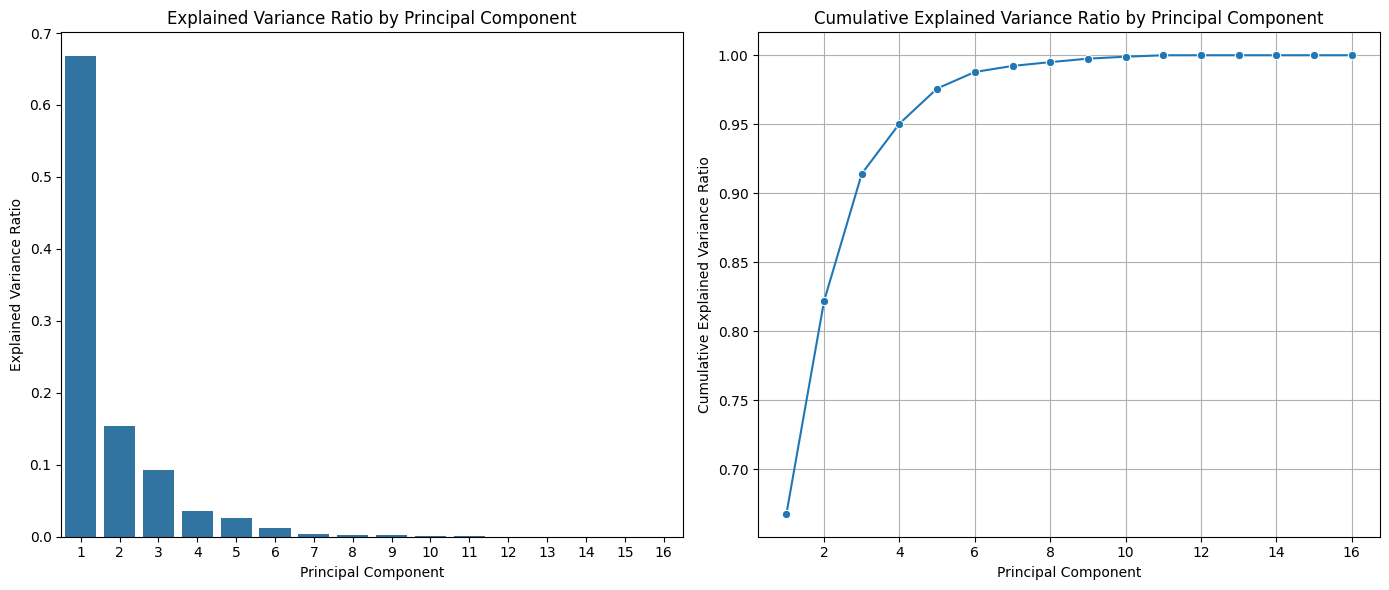

In [ ]:
# PCA 객체 생성 및 적합
pca = PCA()
pca.fit(X_hospital)

# 주성분의 분산 비율 및 누적 분산 비율 계산
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

# 주성분의 분산 비율 히스토그램
plt.figure(figsize=(14, 6))

# 분산 비율 히스토그램
plt.subplot(1, 2, 1)
sns.barplot(x=np.arange(1, len(explained_variance_ratio) + 1), y=explained_variance_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')

# 누적 분산 비율 선 그래프
plt.subplot(1, 2, 2)
sns.lineplot(x=np.arange(1, len(cumulative_explained_variance_ratio) + 1), y=cumulative_explained_variance_ratio, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Component')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# PCA 객체 생성 (주성분 개수 10으로 설정)
n_components = 10
pca = PCA(n_components=n_components)
pca.fit(X_hospital)

# PCA 결과 DataFrame 생성
principal_components_hospital = pca.transform(X_hospital)
pca_df_hospital = pd.DataFrame(data=principal_components_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_hospital = pd.concat([location_data_hospital.reset_index(drop=True), pca_df_hospital.reset_index(drop=True)], axis=1)

# PCA 결과 확인
explained_variance_ratio = pca.explained_variance_ratio_
components = pca.components_

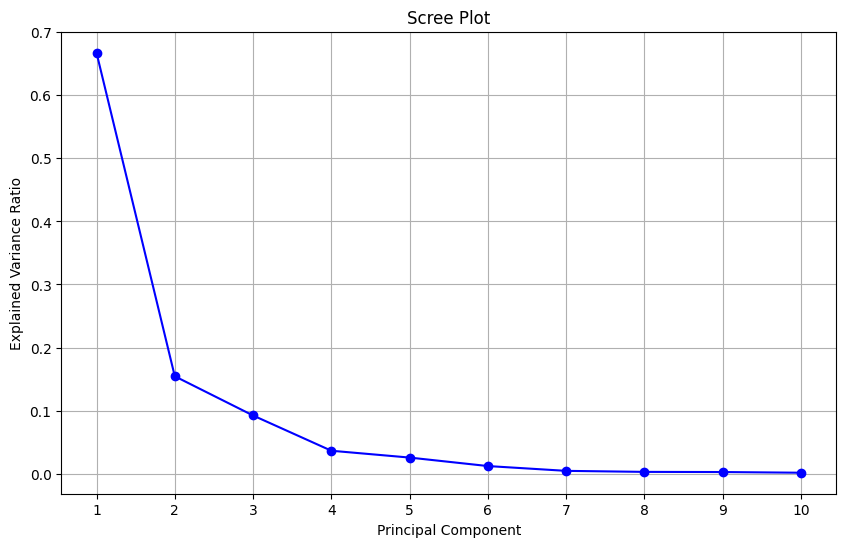

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

`Note`
- 활용할 주성분 개수를 4개로 정함
- 설명분산 비율 95%, scree plot에서 기울기가 완만해지는 지점

## `02` 각 주성분 특성확인

In [ ]:
# 각 주성분의 원래 특성 기여도 확인
feature_names = df_numeric_scaled.columns
for i, component in enumerate(components):
    print(f"PC{i+1} 주요 특성:")
    component_contributions = zip(feature_names, component)
    sorted_contributions = sorted(component_contributions, key=lambda x: abs(x[1]), reverse=True)
    for feature, contribution in sorted_contributions[:5]:  # 상위 5개 특성만 표시
        print(f"{feature}: {contribution}")
    print("\n")

PC1 주요 특성:
치매전담형 장기요양기관 종사자수: 0.524688237796629
치매전담형 장기요양기관 수: 0.4654399982336365
치매전담형 장기요양기관 정원: 0.4497144330978347
기초연금_수급권자수: 0.314891464666084
종사자 수: 0.22583553433741588


PC2 주요 특성:
경도인지장애 환자유병률: 0.4231619212760083
치매환자유병률: 0.4162677159739649
치매환자수: 0.35186963770345014
중증 환자: 0.3518694408936193
경도인지장애 환자수: 0.3078863931484291


PC3 주요 특성:
치매환자유병률: 0.4626549637384134
경도인지장애 환자유병률: 0.43660158336480587
독거노인가구비율: 0.3003079824846754
중증 환자: -0.27919468251296325
치매환자수: -0.27919396130232027


PC4 주요 특성:
기초연금_수급권자수: -0.6259016846791059
치매전담형 장기요양기관 정원: 0.4968758426274016
시설 수: -0.39606063547782333
종사자 수: -0.27156004450867804
정원: -0.23603042757318982


PC5 주요 특성:
시설 수: -0.6756694746270551
독거노인가구비율: -0.4632725797304752
기초연금_수급권자수: 0.2698799744526955
치매환자유병률: 0.2670982852763956
경도인지장애 환자유병률: 0.2661584912411107


PC6 주요 특성:
독거노인가구비율: 0.47717160644986134
정원: -0.46751630103165154
기초연금_수급권자수: 0.46256024464565804
시설 수: -0.3838164013741498
종사자 수: -0.29514851439147205


PC7 주요 특성:
종사자 수: 0.60973964

`Note`
- 각 주성분 해석
  - PC1 : 치매 관련 시설의 규모와 관련
  - PC2 : 인지장애와 치매 관련 건강 상태와 관련
  - PC3 : 인지장애와 치매 유병률 및 독거노인 비율과 관련
  - PC4 : 기초연금 수급자와 치매전담형 장기요양기관의 정원과 관련

## `03` 점수 합산

In [ ]:
# 병원이 없는 지역 데이터 준비
X_no_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 0].values
location_data_no_hospital = location_data[df['치매안심병원 유무'] == 0]

# 병원이 없는 지역의 주성분 점수 계산
principal_components_no_hospital = pca.transform(X_no_hospital)

# 병원이 없는 지역 DataFrame 생성
pca_df_no_hospital = pd.DataFrame(data=principal_components_no_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_no_hospital = pd.concat([location_data_no_hospital.reset_index(drop=True), pca_df_no_hospital.reset_index(drop=True)], axis=1)

# 각 설명분산비율만큼 주성분에 대한 가중치 설정
weights = np.zeros(n_components)
if n_components > 0:
    weights[0] = 0.67  # PC1의 가중치
if n_components > 1:
    weights[1] = 0.19  # PC2의 가중치
if n_components > 2:
    weights[2] = 0.09  # PC3의 가중치
if n_components > 3:
    weights[3] = 0.04  # PC4의 가중치


# 종합 점수 계산
pca_df_no_hospital['Composite_Score'] = pca_df_no_hospital[[f'PC{i+1}' for i in range(n_components)]].dot(weights)

In [ ]:
# 상위 10개 지역 선택
top_locations = pca_df_no_hospital.sort_values(by='Composite_Score', ascending=False).head(30)

# 상위 10개 지역 출력
print("Top 10 Locations by Composite Score:")
print(top_locations[['Composite_Score', '시도', '시군구']])

Top 10 Locations by Composite Score:
     Composite_Score     시도      시군구
68          5.455379    경기도   경기_수원시
79          4.006092    경기도  경기_남양주시
86          3.472931    경기도   경기_파주시
52          3.212045  인천광역시   인천_남동구
132         3.009409   충청남도   충남_당진시
76          2.945488    경기도   경기_고양시
75          2.273629    경기도   경기_안산시
64          1.669163  울산광역시    울산_중구
46          1.535274  대구광역시   대구_달서구
117         1.518479   충청북도   충북_충주시
172         1.500200   경상북도   경북_포항시
134         1.487944   충청남도   충남_부여군
116         1.355377   충청북도   충북_청주시
85          1.341763    경기도   경기_용인시
174         1.291102   경상북도   경북_구미시
151         1.214849   전라남도   전남_목포시
173         1.193012   경상북도   경북_경주시
70          1.066650    경기도  경기_의정부시
153         1.003168   전라남도   전남_순천시
191         0.988234   경상남도   경남_진주시
73          0.972986    경기도   경기_평택시
53          0.681933  인천광역시   인천_부평구
60          0.582923  대전광역시    대전_동구
18          0.551185  서울특별시   서울_동작구
21          0.371149  서울특별시   서울_강남구
1

# 3.지도 시각화

노인 친화형 다세대 놀이터 방법론 참고 : https://github.com/CSJ516/Optimal_location_selection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# XLSX 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/IBAS ALPHA/data/치매안심병원_프로젝트/step2/step2_1_수정2.xlsx'

# XLSX 파일 읽어오기
try:
    Hospital_df = pd.read_excel(file_path)  # 기본 시트 및 기본 설정으로 엑셀 파일 읽기
    print("File read successfully.")
except Exception as e:
    print(f"Failed to read the file: {e}")

# 조건에 맞는 행 필터링
filtered_df = Hospital_df[
    (Hospital_df['종별코드명'].isin(['병원', '상급종합', '종합병원', '요양병원'])) &  # '종별코드명'이 조건에 맞는 행만 선택
    (Hospital_df['시군구코드명'].str.contains('수원'))  # '시군구코드명'에 '수원'을 포함하는 행만 선택
]

# 필요한 열만 선택하여 새로운 데이터프레임 구성
Hospital_Suwon = filtered_df[['암호화요양기호', '요양기관명', '종별코드명', '시군구코드명', '좌표(X)', '좌표(Y)']]

# 결과 출력
Hospital_Suwon.info()

File read successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   암호화요양기호  38 non-null     object 
 1   요양기관명    38 non-null     object 
 2   종별코드명    38 non-null     object 
 3   시군구코드명   38 non-null     object 
 4   좌표(X)    38 non-null     float64
 5   좌표(Y)    38 non-null     float64
dtypes: float64(2), object(4)
memory usage: 1.9+ KB


In [ ]:
import pandas as pd

# CSV 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/IBAS ALPHA/data/치매안심병원_프로젝트/step2/suwon_subway.csv'

# CSV 파일 읽어오기
try:
    subway_df = pd.read_csv(file_path)  # 기본 설정으로 CSV 파일 읽기
    print("File read successfully.")
except Exception as e:
    print(f"Failed to read the file: {e}")

# 필요한 열만 선택하여 새로운 데이터프레임 구성
Subway_Suwon = subway_df[['line', 'name', 'lat', 'lng']]

# 결과 출력
Subway_Suwon

File read successfully.


,line,name,lat,lng
0,01호선,성균관대,37.300349,126.970750
1,01호선,화서,37.283862,126.989627
2,01호선,수원,37.265974,126.999874
3,01호선,세류,37.245025,127.013222
4,분당선,청명,37.259489,127.078934
5,분당선,영통,37.251568,127.071394
6,분당선,망포,37.245795,127.057353
7,분당선,매탄권선,37.252759,127.040566
8,분당선,수원시청,37.261911,127.030736
9,분당선,매교,37.265481,127.015678


In [ ]:
import pandas as pd
from google.colab import files

# CSV 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/IBAS ALPHA/data/치매안심병원_프로젝트/step2/busStop.csv'

# CSV 파일 읽어오기 (EUC-KR 인코딩 사용)
try:
    bus_df = pd.read_csv(file_path, encoding='euc-kr')  # 인코딩을 EUC-KR로 설정하여 파일 읽기
    print("File read successfully.")
except Exception as e:
    print(f"Failed to read the file: {e}")

# 필요한 열만 선택하여 새로운 데이터프레임 구성
try:
    Bus_Suwon = bus_df[['정류장번호', '정류장명', '위도', '경도', '도시명']]
    print("Columns selected successfully.")
except KeyError as e:
    print(f"Failed to select columns: {e}")

# '도시명' 열에서 '수원시'라는 문자값이 포함된 행들만 필터링
try:
    Bus_Suwon_filtered = Bus_Suwon[Bus_Suwon['도시명'].str.contains('수원시')]
    print("Filtering completed successfully.")
    print(Bus_Suwon_filtered)
except KeyError as e:
    print(f"Failed to filter data: {e}")

# 결과 출력
Bus_Suwon_filtered

File read successfully.
Columns selected successfully.
Filtering completed successfully.
              정류장번호             정류장명         위도          경도      도시명
55675  GGB200000122     수원미술전시관.만석공원  37.296600  126.999267  경기도 수원시
55676  GGB200000123  만석공원.정자초교.벽산아파트  37.299383  126.996317  경기도 수원시
55677  GGB200000124     경남아너스빌.동신아파트  37.303467  126.996800  경기도 수원시
55678  GGB200000125         벽산블루밍아파트  37.305533  126.995017  경기도 수원시
55679  GGB200000126          북수원시장입구  37.306667  126.991567  경기도 수원시
...             ...              ...        ...         ...      ...
99673  GGB277102625      서부공용차고지(경유)  37.254633  126.962950  경기도 수원시
99688  GGB277102645        벌말교차로(경유)  37.259600  126.998750  경기도 수원시
99691  GGB277102650        세류사거리(경유)  37.254217  127.011050  경기도 수원시
99739  GGB277103885        권선사거리(경유)  37.259683  127.024000  경기도 수원시
99740  GGB277103886        못골사거리(경유)  37.285683  127.027667  경기도 수원시

[1527 rows x 5 columns]


,정류장번호,정류장명,위도,경도,도시명
55675,GGB200000122,수원미술전시관.만석공원,37.296600,126.999267,경기도 수원시
55676,GGB200000123,만석공원.정자초교.벽산아파트,37.299383,126.996317,경기도 수원시
55677,GGB200000124,경남아너스빌.동신아파트,37.303467,126.996800,경기도 수원시
55678,GGB200000125,벽산블루밍아파트,37.305533,126.995017,경기도 수원시
55679,GGB200000126,북수원시장입구,37.306667,126.991567,경기도 수원시
...,...,...,...,...,...
99673,GGB277102625,서부공용차고지(경유),37.254633,126.962950,경기도 수원시
99688,GGB277102645,벌말교차로(경유),37.259600,126.998750,경기도 수원시
99691,GGB277102650,세류사거리(경유),37.254217,127.011050,경기도 수원시
99739,GGB277103885,권선사거리(경유),37.259683,127.024000,경기도 수원시


In [ ]:
# import pandas as pd
# from google.colab import files

# # 데이터프레임을 CSV 파일로 저장
# output_file_name = 'Bus_Suwon_filtered.csv'
# try:
#     Bus_Suwon_filtered.to_csv(output_file_name, encoding='euc-kr', index=False)
#     print(f"File saved successfully as {output_file_name}")

#     # 파일을 다운로드하도록 설정
#     files.download(output_file_name)
# except Exception as e:
#     print(f"Failed to save the file: {e}")

File saved successfully as Bus_Suwon_filtered.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## `01` 병원만 지도에 표시

In [ ]:
import pandas as pd
import folium
import requests

# 한국 지도의 중심 좌표 설정 (예: 서울)
map_korea = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 데이터프레임의 각 행에 대해 마커 추가
for idx, row in Hospital_Suwon.iterrows():
    if not pd.isnull(row['좌표(X)']) and not pd.isnull(row['좌표(Y)']):
        folium.Marker(
            location=[row['좌표(Y)'], row['좌표(X)']],  # 위도(Y), 경도(X) 순서로 수정
            popup=row['요양기관명'],
            tooltip=row['요양기관명'],
        ).add_to(map_korea)

# # 대체 수원시 GeoJSON 경계 데이터 가져오기
# url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/KOR.geo.json"
# geojson_data = requests.get(url).json()

# # GeoJSON에서 수원시의 경계만 필터링
# suwon_geojson = {
#     "type": "FeatureCollection",
#     "features": [
#         feature for feature in geojson_data["features"]
#         if "Suwon" in feature["properties"]["name"]
#     ]
# }

# # 수원시 경계를 지도에 추가
# folium.GeoJson(
#     suwon_geojson,
#     name="Suwon Boundary"
# ).add_to(map_korea)

# 지도를 출력
map_korea




## `02` 병원 & 버스 & 지하철

In [ ]:
import pandas as pd
import folium
import requests

# 한국 지도의 중심 좌표 설정 (예: 서울)
map_korea = folium.Map(location=[36.5, 127.5], zoom_start=7)

# Hospital_Suwon 데이터프레임의 각 행에 대해 마커 추가 (기존 마커 유지)
for idx, row in Hospital_Suwon.iterrows():
    if not pd.isnull(row['좌표(X)']) and not pd.isnull(row['좌표(Y)']):
        folium.Marker(
            location=[row['좌표(Y)'], row['좌표(X)']],  # 위도(Y), 경도(X) 순서로 수정
            popup=row['요양기관명'],
            tooltip=row['요양기관명'],
            icon=folium.Icon(color='blue', icon='info-sign')  # 파란색 마커
        ).add_to(map_korea)

# Subway_Suwon 데이터프레임의 각 행에 대해 마커 추가 (새로운 마커)
for idx, row in Subway_Suwon.iterrows():
    if not pd.isnull(row['lat']) and not pd.isnull(row['lng']):
        folium.Marker(
            location=[row['lat'], row['lng']],
            popup=row['name'],
            tooltip=row['name'],
            icon=folium.Icon(color='green', icon='train')  # 녹색 마커
        ).add_to(map_korea)

# Bus_Suwon_filtered 데이터프레임의 각 행에 대해 마커 추가 (새로운 마커)
for idx, row in Bus_Suwon_filtered.iterrows():
    if not pd.isnull(row['경도']) and not pd.isnull(row['위도']):
        folium.Marker(
            location=[row['위도'], row['경도']],
            popup=row['정류장명'],
            tooltip=row['정류장명'],
            icon=folium.Icon(color='red', icon='cloud')  # 빨간색 마커
        ).add_to(map_korea)

# 대체 수원시 GeoJSON 경계 데이터 가져오기
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/KOR.geo.json"
geojson_data = requests.get(url).json()

# GeoJSON에서 수원시의 경계만 필터링
suwon_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature for feature in geojson_data["features"]
        if "Suwon" in feature["properties"]["name"]
    ]
}

# 수원시 경계를 지도에 추가
folium.GeoJson(
    suwon_geojson,
    name="Suwon Boundary"
).add_to(map_korea)

# 지도를 출력
map_korea


## `03` 병원 & 지하철

In [ ]:
import pandas as pd
import folium
import requests

# 한국 지도의 중심 좌표 설정 (예: 서울)
map_korea = folium.Map(location=[36.5, 127.5], zoom_start=7)

# Hospital_Suwon 데이터프레임의 각 행에 대해 마커 추가 (기존 마커 유지)
for idx, row in Hospital_Suwon.iterrows():
    if not pd.isnull(row['좌표(X)']) and not pd.isnull(row['좌표(Y)']):
        folium.Marker(
            location=[row['좌표(Y)'], row['좌표(X)']],  # 위도(Y), 경도(X) 순서로 수정
            popup=row['요양기관명'],
            tooltip=row['요양기관명'],
            icon=folium.Icon(color='blue', icon='info-sign')  # 파란색 마커
        ).add_to(map_korea)

# Subway_Suwon 데이터프레임의 각 행에 대해 마커 추가 (새로운 마커)
for idx, row in Subway_Suwon.iterrows():
    if not pd.isnull(row['lat']) and not pd.isnull(row['lng']):
        folium.Marker(
            location=[row['lat'], row['lng']],
            popup=row['name'],
            tooltip=row['name'],
            icon=folium.Icon(color='green', icon='train')  # 녹색 마커
        ).add_to(map_korea)

# Bus_Suwon_filtered 데이터프레임의 각 행에 대해 마커 추가 부분을 주석 처리
# for idx, row in Bus_Suwon_filtered.iterrows():
#     if not pd.isnull(row['경도']) and not pd.isnull(row['위도']):
#         folium.Marker(
#             location=[row['위도'], row['경도']],
#             popup=row['정류장명'],
#             tooltip=row['정류장명'],
#             icon=folium.Icon(color='red', icon='cloud')  # 빨간색 마커
#         ).add_to(map_korea)

# 대체 수원시 GeoJSON 경계 데이터 가져오기
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/KOR.geo.json"
geojson_data = requests.get(url).json()

# GeoJSON에서 수원시의 경계만 필터링
suwon_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature for feature in geojson_data["features"]
        if "Suwon" in feature["properties"]["name"]
    ]
}

# 수원시 경계를 지도에 추가
folium.GeoJson(
    suwon_geojson,
    name="Suwon Boundary"
).add_to(map_korea)

# 지도를 출력
map_korea


# 4.STEP 2 : P-median

In [ ]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 13.9 MB/s eta 0:00:00


In [ ]:
Hospital_Suwon['좌표(Y)'] = pd.to_numeric(Hospital_Suwon['좌표(Y)'], errors='coerce')
Hospital_Suwon['좌표(X)'] = pd.to_numeric(Hospital_Suwon['좌표(X)'], errors='coerce')

Subway_Suwon['lat'] = pd.to_numeric(Subway_Suwon['lat'], errors='coerce')
Subway_Suwon['lng'] = pd.to_numeric(Subway_Suwon['lng'], errors='coerce')

Bus_Suwon_filtered['위도'] = pd.to_numeric(Bus_Suwon_filtered['위도'], errors='coerce')
Bus_Suwon_filtered['경도'] = pd.to_numeric(Bus_Suwon_filtered['경도'], errors='coerce')


<ipython-input-6-98107ba897aa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hospital_Suwon['좌표(Y)'] = pd.to_numeric(Hospital_Suwon['좌표(Y)'], errors='coerce')
<ipython-input-6-98107ba897aa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Hospital_Suwon['좌표(X)'] = pd.to_numeric(Hospital_Suwon['좌표(X)'], errors='coerce')
<ipython-input-6-98107ba897aa>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [ ]:
import pandas as pd
import folium
from pulp import *
import numpy as np
from geopy.distance import great_circle

# Hospital_Suwon 데이터프레임의 각 병원을 후보지로 설정
hospital_candidates = Hospital_Suwon[['요양기관명', '좌표(Y)', '좌표(X)']].dropna().values.tolist()

# Subway_Suwon의 컬럼 이름을 통일 (예: 'lat', 'lng'로 표준화)
Subway_Suwon.rename(columns={'lat': 'latitude', 'lng': 'longitude'}, inplace=True)

# Bus_Suwon_filtered의 컬럼 이름을 통일 (예: '위도', '경도'를 'latitude', 'longitude'로 표준화)
Bus_Suwon_filtered.rename(columns={'위도': 'latitude', '경도': 'longitude'}, inplace=True)

# 표준화된 데이터프레임 결합
demand_points = pd.concat([Subway_Suwon[['name', 'latitude', 'longitude']],
                           Bus_Suwon_filtered[['정류장명', 'latitude', 'longitude']]])

# 결합 후 NaN 값 제거
demand_points = demand_points.dropna().values.tolist()

# p-median 문제 설정
p = 1  # 설치할 시설의 수

# 후보지와 수요지 간의 거리를 계산
distances = np.zeros((len(demand_points), len(hospital_candidates)))

for i, demand in enumerate(demand_points):  # enumerate를 사용하여 demand_points 리스트의 인덱스(i)와 값(demand)을 반복
    for j, candidate in enumerate(hospital_candidates):  # enumerate를 사용하여 hospital_candidates 리스트의 인덱스(j)와 값(candidate)을 반복
        distances[i, j] = great_circle((demand[1], demand[2]), (candidate[1], candidate[2])).meters  # demand와 candidate 간의 거리(meter 단위)를 계산하여 distances 배열의 해당 위치에 저장

# Pulp 문제 생성
problem = LpProblem("p-median-problem", LpMinimize)

# 변수 생성
x = LpVariable.dicts('x', range(len(hospital_candidates)), cat='Binary')
y = LpVariable.dicts('y', [(i, j) for i in range(len(demand_points)) for j in range(len(hospital_candidates))], cat='Binary')

# 목적 함수 설정
problem += lpSum([distances[i][j] * y[(i, j)] for i in range(len(demand_points)) for j in range(len(hospital_candidates))])

# 제약 조건 추가
# 각 수요지는 반드시 한 후보지에 할당되어야 함
for i in range(len(demand_points)):
    problem += lpSum([y[(i, j)] for j in range(len(hospital_candidates))]) == 1

# 선택된 후보지의 수는 p 이하
problem += lpSum([x[j] for j in range(len(hospital_candidates))]) == p

# 수요지는 선택된 후보지에만 할당될 수 있음
for i in range(len(demand_points)):
    for j in range(len(hospital_candidates)):
        problem += y[(i, j)] <= x[j]

# 문제 해결
problem.solve()

# 선택된 병원 후보지 인덱스
selected_hospitals = [j for j in range(len(hospital_candidates)) if x[j].varValue > 0]

# 기본 지도 생성 시 CartoDB Positron 타일셋을 사용하여 배경을 흑백으로 설정
map_korea = folium.Map(
    location=[36.5, 127.5],
    zoom_start=7,
    tiles='CartoDB positron',
    attr="Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL."
)

# 후보 병원 마커 추가 (붉은 색의 점 형태로 변경 및 텍스트 추가)
for j in selected_hospitals:
    folium.CircleMarker(
        location=[hospital_candidates[j][1], hospital_candidates[j][2]],
        radius=7,  # 점의 크기
        color='red',  # 붉은 색 점
        fill=True,
        fill_opacity=0.7,  # 점의 투명도
        popup=hospital_candidates[j][0],
        tooltip=hospital_candidates[j][0]  # 마우스 오버 시 지역명이 텍스트로 표시되도록 설정
    ).add_to(map_korea)


# 지도를 HTML 파일로 저장하여 구글 코랩에서 표시
map_korea.save('map_korea.html')


<ipython-input-39-50f79082c8f4>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Subway_Suwon.rename(columns={'lat': 'latitude', 'lng': 'longitude'}, inplace=True)
<ipython-input-39-50f79082c8f4>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bus_Suwon_filtered.rename(columns={'위도': 'latitude', '경도': 'longitude'}, inplace=True)


In [ ]:
# 지도 표시
from IPython.display import IFrame
from google.colab import files

# 파일 다운로드 링크 제공
files.download('map_korea.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import folium

# 이미 생성된 map_korea를 불러와서 Subway_Suwon, Bus_Suwon_filtered 마커 추가

# Subway_Suwon 데이터프레임의 각 행에 대해 마커 추가 (연한 녹색 점으로 표시)
for idx, row in Subway_Suwon.iterrows():
    if not pd.isnull(row['latitude']) and not pd.isnull(row['longitude']):
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,  # 점의 크기
            color='lightgreen',  # 연한 녹색 점
            fill=True,
            fill_opacity=0.5,  # 점의 투명도
            popup=row['name'],
            tooltip=row['name']
        ).add_to(map_korea)

# Bus_Suwon_filtered 데이터프레임의 각 행에 대해 마커 추가 (연한 파란 점으로 표시)
for idx, row in Bus_Suwon_filtered.iterrows():
    if not pd.isnull(row['latitude']) and not pd.isnull(row['longitude']):
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,  # 점의 크기
            color='lightblue',
            fill=True,
            fill_opacity=0.5,  # 점의 투명도
            popup=row['정류장명'],
            tooltip=row['정류장명']
        ).add_to(map_korea)

# 이미지를 다시 저장
map_korea.save('map_korea_with_additional_points.html')

# 파일 다운로드 제공
files.download('map_korea_with_additional_points.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 5.STEP 2 : 반경 1km 수요지 스코어링

- 병원 입지를 정하기 위해 공간 최적화 기법인 p-median을 사용하려고 하였으나
  - 각 병원의 교통 접근성, 편리성을 측정하고자 하는 분석목적상
  - 기존 p-median : 전체적인 버스나 지하철 정류장을 고려하여 총 이동 거리를 최소화하기는 방식보다는
  - 각 병원에서 도보로 이동가능한 거리를 기준으로(1km) 가까운 거리의 정류장들만 고려하는 것이 맞다고 판단

In [ ]:
import pandas as pd
import folium
import numpy as np
from geopy.distance import great_circle

# Hospital_Suwon 데이터프레임의 각 병원을 후보지로 설정
hospital_candidates = Hospital_Suwon[['요양기관명', '좌표(Y)', '좌표(X)']].dropna().values.tolist()

# Subway_Suwon의 컬럼 이름을 통일 (예: 'lat', 'lng'로 표준화)
Subway_Suwon.rename(columns={'lat': 'latitude', 'lng': 'longitude'}, inplace=True)

# Bus_Suwon_filtered의 컬럼 이름을 통일 (예: '위도', '경도'를 'latitude', 'longitude'로 표준화)
Bus_Suwon_filtered.rename(columns={'위도': 'latitude', '경도': 'longitude'}, inplace=True)

# 표준화된 데이터프레임 결합
demand_points_subway = Subway_Suwon[['name', 'latitude', 'longitude']].dropna().values.tolist()
demand_points_bus = Bus_Suwon_filtered[['정류장명', 'latitude', 'longitude']].dropna().values.tolist()


<ipython-input-41-26d4b9895bef>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Subway_Suwon.rename(columns={'lat': 'latitude', 'lng': 'longitude'}, inplace=True)
<ipython-input-41-26d4b9895bef>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bus_Suwon_filtered.rename(columns={'위도': 'latitude', '경도': 'longitude'}, inplace=True)


In [ ]:
# 중복된 좌표를 가진 병원에 대해 첫 번째 병원만 선택
hospital_candidates_unique = hospital_coordinates.drop_duplicates(subset=['Latitude', 'Longitude'])

# 유니크한 병원 후보지로 점수 계산을 다시 수행
scores = []

for candidate in hospital_candidates_unique.values:
    score = 0
    subway_count = 0  # 지하철 수요지 수를 세는 변수
    bus_count = 0  # 버스 수요지 수를 세는 변수

    for demand in demand_points_subway:  # 모든 지하철 수요지들에 대해 반복문 실행
        distance = great_circle((demand[1], demand[2]), (candidate[1], candidate[2])).meters
        # 현재 지하철 수요지와 병원 후보지 간의 거리 계산 (좌표: demand[1], demand[2] 와 candidate[1], candidate[2])
        if distance <= 1000:  # 계산된 거리가 1000미터(1km) 이내인지 확인
            subway_count += 1  # 1km 이내에 있을 경우 지하철 수요지 카운트를 1 증가시킴

    for demand in demand_points_bus:  # 모든 버스 수요지들에 대해
        distance = great_circle((demand[1], demand[2]), (candidate[1], candidate[2])).meters
        if distance <= 1000:
            bus_count += 1

    score = (subway_count * 2) + bus_count  # 최종 점수 계산: 지하철 수요지 수는 2배의 가중치를 주고, 버스 수요지 수를 더함
    scores.append((candidate, score))  # 후보지와 계산된 점수를 튜플로 만들어 scores 리스트에 추가

# 점수에 따라 후보지 정렬 (내림차순)
scores.sort(key=lambda x: x[1], reverse=True)

# 최상위 3개 후보지 선택 (점수가 높은 순서대로)
selected_hospitals = scores[:3]

In [ ]:
# 점수에 따른 후보지와 점수를 DataFrame으로 변환
df_scores = pd.DataFrame(scores, columns=['Candidate', 'Score'])

# 후보지 이름과 좌표 분리
df_scores['Hospital Name'] = df_scores['Candidate'].apply(lambda x: x[0])
df_scores['Latitude'] = df_scores['Candidate'].apply(lambda x: x[1])
df_scores['Longitude'] = df_scores['Candidate'].apply(lambda x: x[2])

# 불필요한 'Candidate' 컬럼 삭제
df_scores.drop(columns=['Candidate'], inplace=True)

# 점수에 따라 내림차순으로 정렬
df_scores = df_scores.sort_values(by='Score', ascending=False)

# 결과 표 출력
df_scores.reset_index(drop=True, inplace=True)
df_scores

,Score,Hospital Name,Latitude,Longitude
0,95,수원브이아이피요양병원,37.270962,127.001078
1,71,연세수요양병원,37.304457,127.001478
2,68,동서요양병원,37.291190,127.021670
3,67,효정요양병원,37.277708,127.007034
4,66,학교법인 대우학원 아주대학교요양병원,37.279128,127.049127
5,64,메이저요양병원,37.275691,127.027345
6,62,위더스요양병원,37.271756,127.028044
7,61,한빛현요양병원,37.306409,127.000364
8,56,연세엘림요양병원,37.292961,127.009308
9,52,수원삼성요양병원,37.293594,127.001252


In [ ]:
from folium.features import DivIcon

# Folium 지도를 사용하여 결과 시각화
# 기본 지도 생성 시 CartoDB Positron 타일셋을 사용하여 배경을 흑백으로 설정
map_korea = folium.Map(
    location=[36.5, 127.5],
    zoom_start=7,
    tiles='CartoDB positron',
    attr="Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL."
)

# 후보 병원 마커 추가 (선택된 3개 병원 - 붉은 색의 점 형태로 변경 및 텍스트 추가)
for candidate, score in selected_hospitals:
    folium.CircleMarker(
        location=[candidate[1], candidate[2]],
        radius=5,  # 점의 크기
        color='red',  # 붉은 색 점
        fill=True,
        fill_opacity=0.7,  # 점의 투명도
        popup=f"{candidate[0]} - Score: {score}",
        tooltip=candidate[0]  # 마우스 오버 시 지역명이 텍스트로 표시되도록 설정
    ).add_to(map_korea)

    # 텍스트 라벨 추가
    folium.map.Marker(
        [candidate[1], candidate[2]],
        icon=DivIcon(
            icon_size=(150,36),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 12pt; color: black;">{candidate[0]}</div>',
        )
    ).add_to(map_korea)

# 수요지 마커 추가
for demand in demand_points_subway:
    folium.CircleMarker(
        location=[demand[1], demand[2]],
        radius=2,  # 작은 크기
        color='lightgreen',
        fill=True,
        fill_color='lightgreen',
        fill_opacity=0.2
    ).add_to(map_korea)

for demand in demand_points_bus:
    folium.CircleMarker(
        location=[demand[1], demand[2]],
        radius=2,  # 작은 크기
        color='lightblue',
        fill=True,
        fill_color='lightblue',
        fill_opacity=0.2
    ).add_to(map_korea)

# 지도를 HTML 파일로 저장하여 구글 코랩에서 표시
map_korea.save('map_korea.html')

# 파일 다운로드 제공
files.download('map_korea.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

지도에 반경 1km 표시 추가한 코드

In [ ]:
from folium.features import DivIcon
import folium
from google.colab import files

# 기본 지도 생성 시 CartoDB Positron 타일셋을 사용하여 배경을 흑백으로 설정
map_korea = folium.Map(
    location=[36.5, 127.5],
    zoom_start=7,
    tiles='CartoDB positron',
    attr="Map tiles by CartoDB, under CC BY 3.0. Data by OpenStreetMap, under ODbL."
)

# 후보 병원 마커 추가 (선택된 3개 병원 - 붉은 색의 점 형태로 변경 및 텍스트 추가)
for candidate, score in selected_hospitals:
    # 붉은 색 점 형태의 마커 추가
    folium.CircleMarker(
        location=[candidate[1], candidate[2]],
        radius=4,  # 점의 크기
        color='red',  # 붉은 색 점
        fill=True,
        fill_opacity=0.7,  # 점의 투명도
        popup=f"{candidate[0]} - Score: {score}",
        tooltip=candidate[0]  # 마우스 오버 시 지역명이 텍스트로 표시되도록 설정
    ).add_to(map_korea)

    # 텍스트 라벨 추가
    folium.map.Marker(
        [candidate[1], candidate[2]],
        icon=DivIcon(
            icon_size=(150,36),
            icon_anchor=(0,0),
            html=f'<div style="font-size: 12pt; color: black;">{candidate[0]}</div>',
        )
    ).add_to(map_korea)

    # 1km 반경의 원 추가
    folium.Circle(
        location=[candidate[1], candidate[2]],
        radius=1000,  # 반경 1km
        color='red',  # 원의 경계선 색상
        fill=False,  # 원 내부 채우지 않음
    ).add_to(map_korea)

# 수요지 마커 추가
for demand in demand_points_subway:
    folium.CircleMarker(
        location=[demand[1], demand[2]],
        radius=2,  # 작은 크기
        color='lightgreen',
        fill=True,
        fill_color='lightgreen',
        fill_opacity=0.2
    ).add_to(map_korea)

for demand in demand_points_bus:
    folium.CircleMarker(
        location=[demand[1], demand[2]],
        radius=2,  # 작은 크기
        color='lightblue',
        fill=True,
        fill_color='lightblue',
        fill_opacity=0.2
    ).add_to(map_korea)

# 지도를 HTML 파일로 저장하여 구글 코랩에서 표시
map_korea.save('map_korea.html')

# 파일 다운로드 제공
files.download('map_korea.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>